# Part 2, Task c: MLP on RingSyn

scikit-learn `MLPClassifier` with one hidden layer of 8 tanh neurons (adam). Inputs are standardised with the training set's mean and std.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier

# The sweep stops training early on purpose, so hide the "did not converge" warning.
warnings.simplefilter("ignore", ConvergenceWarning)

EPOCHS = [1, 5, 10, 15, 20, 50, 60, 80, 100, 120, 150, 200]


def load(name):
    """Load data/<name>.csv -> (X, y, feature names). The last column is the 0/1 class."""
    path = f"data/{name}.csv"
    names = open(path).readline().strip().split(",")[:-1]
    data = np.loadtxt(path, delimiter=",", skiprows=1)
    return data[:, :-1], data[:, -1].astype(int), names


def make_scaler(X_train):
    """Return a function that standardises with the training set's mean and std (no test leakage)."""
    mean, std = X_train.mean(axis=0), X_train.std(axis=0)
    return lambda X: (X - mean) / std


def build_mlp(epochs):
    """One hidden layer of 8 tanh neurons. For adam, max_iter is the number of epochs."""
    return MLPClassifier(hidden_layer_sizes=(8,), activation="tanh", solver="adam",
                         max_iter=epochs, random_state=42)

In [2]:
def epoch_sweep(train, test):
    """Train a fresh MLP for each epoch count, print its test accuracy, then plot the boundaries."""
    (X_train, y_train, names), (X_test, y_test, _) = load(train), load(test)
    scale = make_scaler(X_train)
    results = []
    print("| Model (epoch) | Accuracy |\n|---------------|----------|")
    for epochs in EPOCHS:
        model = build_mlp(epochs).fit(scale(X_train), y_train)
        accuracy = np.mean(model.predict(scale(X_test)) == y_test)
        results.append((epochs, accuracy, model))
        print(f"| {f'MLP ({epochs})':<13} | {accuracy:8.3f} |")
    name = train.removesuffix("Train")
    plot_boundaries(results, X_train, y_train, names, scale,
                    f"{name}: MLP decision boundary after each number of epochs (shading = predicted class)",
                    f"mlp_{name}")


def plot_boundaries(results, X, y, names, scale, title, filename):
    """One panel per (epochs, accuracy, model), 4 per row: the decision boundary over the first two
    features in original units. Any other feature (SeaSyn's attrib3) is fixed at its training mean."""
    pad = 0.05 * np.ptp(X[:, :2], axis=0)
    lo, hi = X[:, :2].min(axis=0) - pad, X[:, :2].max(axis=0) + pad
    xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], 300), np.linspace(lo[1], hi[1], 300))
    grid = np.tile(X.mean(axis=0), (xx.size, 1))
    grid[:, 0], grid[:, 1] = xx.ravel(), yy.ravel()

    rows, cols = -(-len(results) // 4), min(len(results), 4)
    fig, axes = plt.subplots(rows, cols, figsize=(max(3.5 * cols, 6), max(3.5 * rows, 5.5)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, (epochs, accuracy, model) in zip(axes.flat, results):
        zz = model.predict(scale(grid)).reshape(xx.shape)
        ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#c6dbef", "#fdd0a2"])
        ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1)
        ax.scatter(*X[y == 0, :2].T, s=10, color="tab:blue", label="class 0")
        ax.scatter(*X[y == 1, :2].T, s=12, color="tab:orange", marker="x", label="class 1")
        ax.set_title(f"{epochs} epoch{'s' * (epochs > 1)}: test acc {accuracy:.3f}", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel(names[0])
    for ax in axes[:, 0]:
        ax.set_ylabel(names[1])
    axes[0, 0].legend(fontsize=7, loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(f"figures/{filename}.png", dpi=150)
    plt.show()

## Epoch sweep: RingSyn

| Model (epoch) | Accuracy |
|---------------|----------|
| MLP (1)       |    0.673 |
| MLP (5)       |    0.677 |
| MLP (10)      |    0.700 |
| MLP (15)      |    0.730 |


| MLP (20)      |    0.737 |
| MLP (50)      |    0.767 |


| MLP (60)      |    0.760 |


| MLP (80)      |    0.780 |


| MLP (100)     |    0.787 |


| MLP (120)     |    0.807 |


| MLP (150)     |    0.813 |


| MLP (200)     |    0.833 |


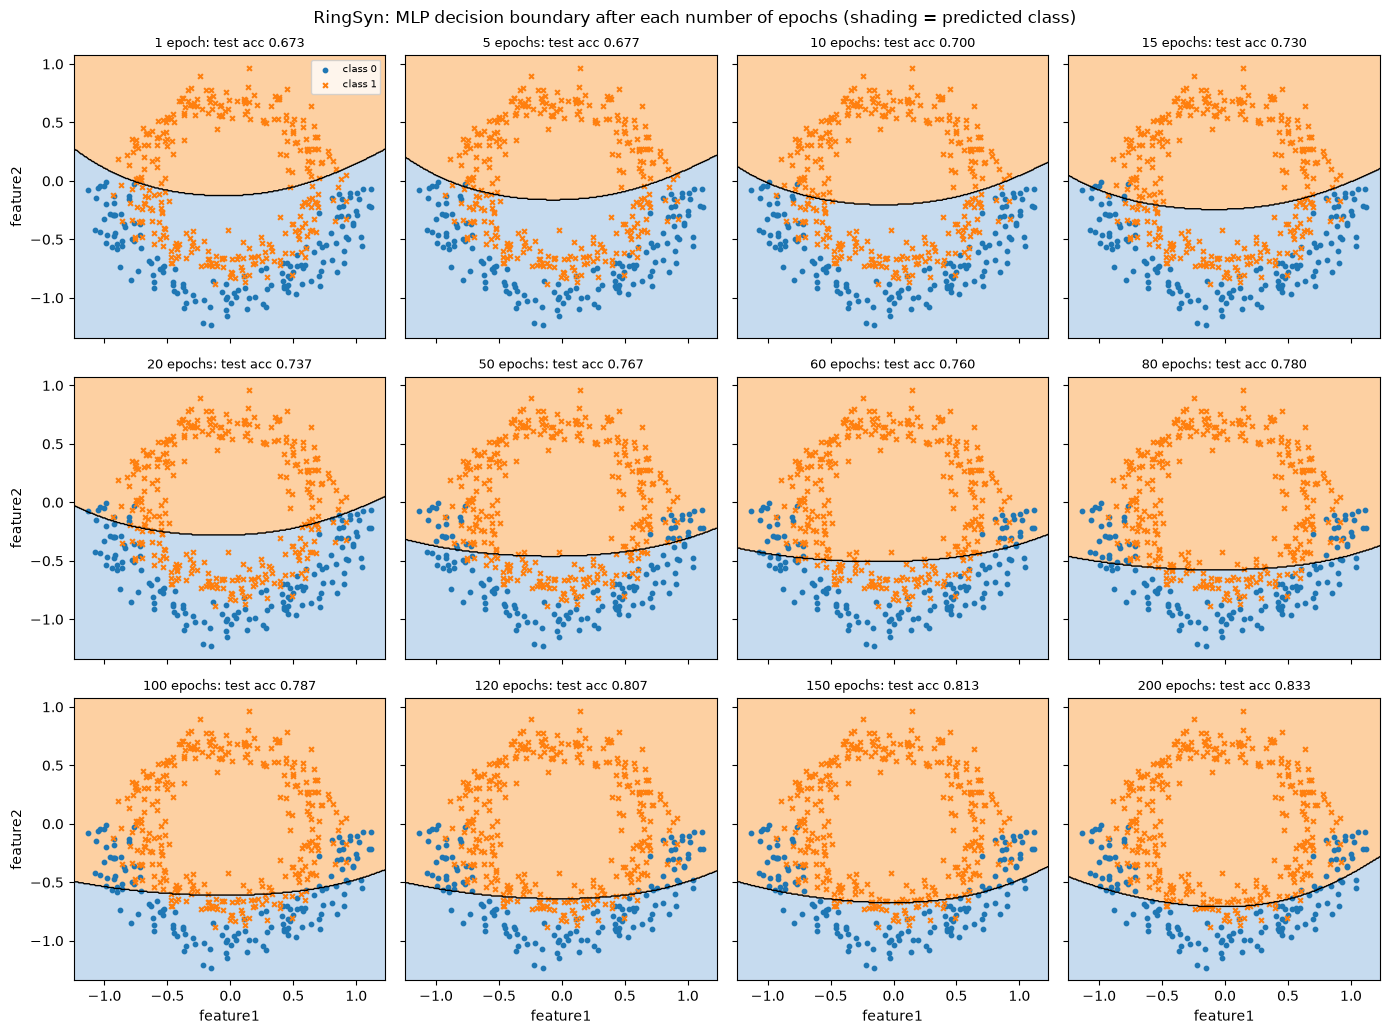

In [3]:
epoch_sweep("RingSynTrain", "RingSynTest")

## Final model: trained until the loss converges (max 2000 epochs)

Trained for 1113 epochs
Train accuracy: 0.927
Test accuracy:  0.937


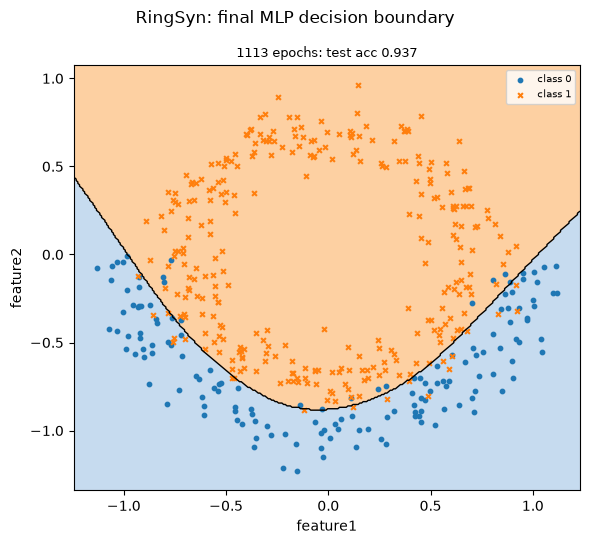

In [4]:
(X_train, y_train, names), (X_test, y_test, _) = load("RingSynTrain"), load("RingSynTest")
scale = make_scaler(X_train)
model = build_mlp(2000).fit(scale(X_train), y_train)
accuracy = model.score(scale(X_test), y_test)

print(f"Trained for {model.n_iter_} epochs")
print(f"Train accuracy: {model.score(scale(X_train), y_train):.3f}")
print(f"Test accuracy:  {accuracy:.3f}")
plot_boundaries([(model.n_iter_, accuracy, model)], X_train, y_train, names, scale,
                "RingSyn: final MLP decision boundary", "mlp_RingSyn_final")